# Import Library & Set Globals

In [2]:
# base
import os
import sys
import warnings
import logging
import pickle

# data manipulation
import pickle
import pandas as pd
import itables
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# single cell
import scanpy as sc
import decoupler as dc
import gseapy as gp

itables.init_notebook_mode(connected=True)  # Use connected=False for offline use
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

from rpy2.robjects.conversion import localconverter

converter = get_converter()

# R_preload()
%load_ext rpy2.ipython

study = "GonzalezHurtado2025"

CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]

%matplotlib inline
mpl.rcdefaults()

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-11-10 13:45:37 | [INFO] cffi mode is CFFI_MODE.ANY
2025-11-10 13:45:37 | [INFO] R home found: /opt/R/4.4.1/lib/R
2025-11-10 13:45:37 | [INFO] R library path: /opt/R/4.4.1/lib/R/lib:/usr/local/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-11-openjdk-amd64/lib/server
2025-11-10 13:45:37 | [INFO] LD_LIBRARY_PATH: /opt/R/4.4.1/lib/R/lib:/usr/local/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-11-openjdk-amd64/lib/server
2025-11-10 13:45:37 | [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2025-11-10 13:45:38 | [INFO] Environment variable "PWD" redefined by R and overriding existing variable. Current: "/mnt/DATA/home/ethung", R: "/mnt/DATA/home/ethung/spatial_seq/src/notebooks/single_cell"
2025-11-10 13:45:38 | [INFO] R is already initialized. No need to initialize.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-

# Access adata

In [2]:
study_name = "GonzalezHurtado_download"

# experiment = os.path.join('cellbender',study)
# filename = "output_filtered"
# filetype = ".h5"
# data_dir = DATADIR

experiment_dir = Path("cellranger", study_name)
filename = "1/outs/raw_feature_bc_matrix"
filetype = ".mtx"
data_dir = DATADIR
convertR = False

adatas = GetSingleCellData(DATADIR, experiment_dir, filename, filetype, convertR)

for ad in adatas:
    ad.obs["Groups"] = ad.obs["Identifier"]
    ad.obs["Experiment"], ad.obs["Age"], ad.obs["Gender"] = np.array(
        ad.obs["Identifier"].str.split("_").to_list()
    ).T

In [4]:
np.sum([ad.shape[0] for ad in adatas])

18760

# Filter

Cells removed by gene/count filters: 6 (0.08%)
Cells removed by gene/count filters: 12 (0.97%)
Cells removed by gene/count filters: 15 (0.58%)
Cells removed by gene/count filters: 4 (0.06%)
Cells with >10% mito genes: 759 (9.69%)
Cells with >10% mito genes: 384 (31.45%)
Cells with >10% mito genes: 826 (31.87%)
Cells with >10% mito genes: 978 (13.82%)


... storing 'Identifier' as categorical
... storing 'Groups' as categorical
... storing 'Experiment' as categorical
... storing 'Age' as categorical
... storing 'Gender' as categorical
... storing 'feature_types' as categorical
... storing 'Identifier' as categorical
... storing 'Groups' as categorical
... storing 'Experiment' as categorical
... storing 'Age' as categorical
... storing 'Gender' as categorical
... storing 'feature_types' as categorical
... storing 'Identifier' as categorical
... storing 'Groups' as categorical
... storing 'Experiment' as categorical
... storing 'Age' as categorical
... storing 'Gender' as categorical
... storing 'feature_types' as categorical
... storing 'Identifier' as categorical
... storing 'Groups' as categorical
... storing 'Experiment' as categorical
... storing 'Age' as categorical
... storing 'Gender' as categorical
... storing 'feature_types' as categorical


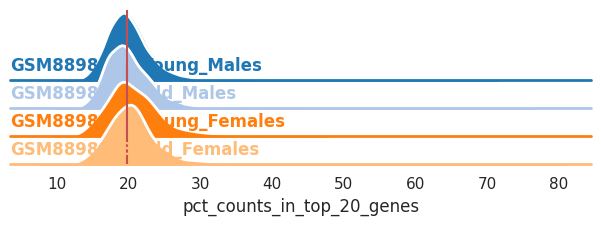

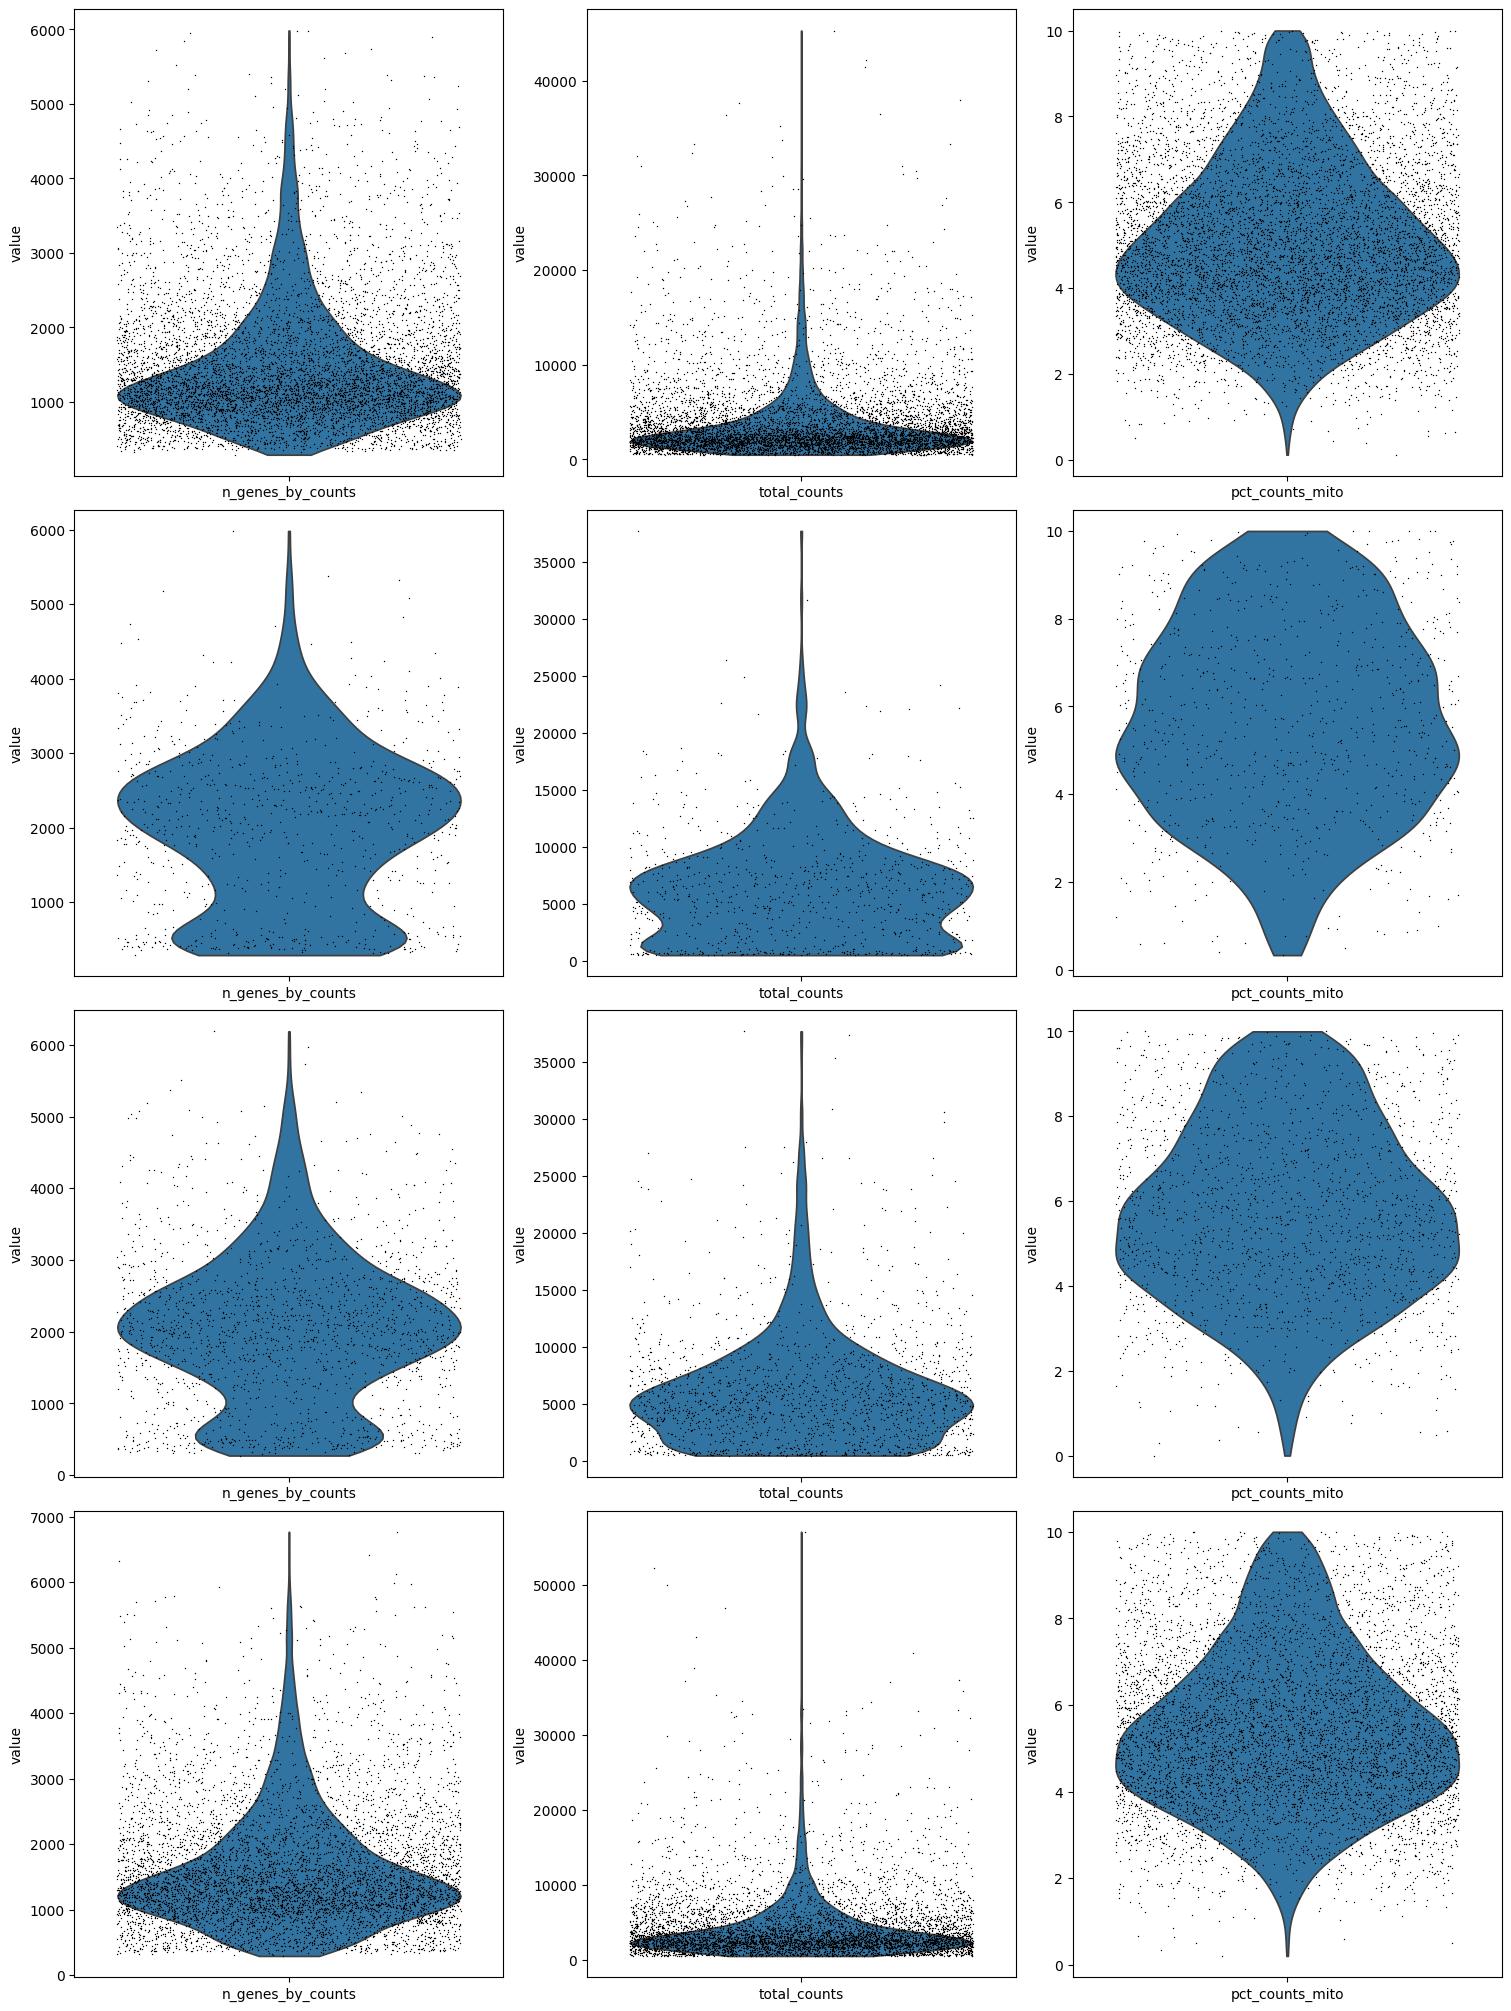

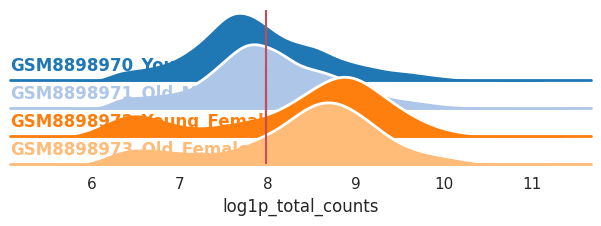

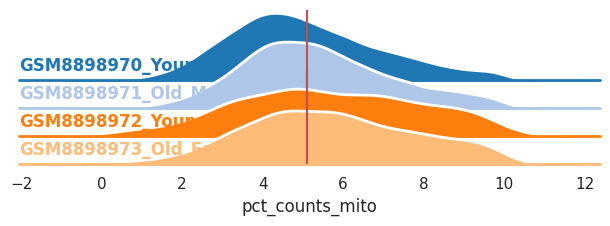

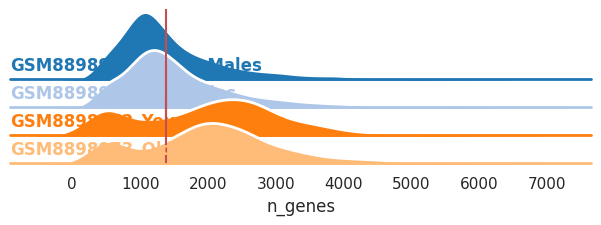

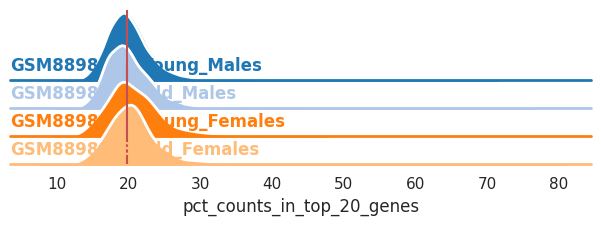

In [4]:
adatas = [Filter_QC(dat, verbose=True) for dat in adatas]
adatas = [Filter_GeneGroup(dat, verbose=True, perc_threshold=10) for dat in adatas]

groupby = "Groups"
f, axs = plt.subplots(len(adatas), 3, figsize=(15, 20), layout="constrained")
for i in range(len(adatas)):
    for n, metric in enumerate(
        ["n_genes_by_counts", "total_counts", "pct_counts_mito"]
    ):
        sc.pl.violin(adatas[i], metric, jitter=0.4, ax=axs[i][n], show=False)
df = pd.concat([x.obs for x in adatas])
df = df.sort_values(groupby)

check_QCPlot(df, "log1p_total_counts", groupby)
check_QCPlot(df, "pct_counts_mito", groupby)
check_QCPlot(df, "n_genes", groupby)
check_QCPlot(df, "pct_counts_in_top_20_genes", groupby)

# Doublets

In [5]:
print("methods available:", DOUBLETMETHODS)
compare_doublets = True
method = "scDblFinder"
method_short = "scDF"

if compare_doublets is True:
    for method in DOUBLETMETHODS:
        adatas = [Filter_Doublet(dat, method, remove=False) for dat in adatas]

else:
    print(f"Doublet method selected: {method}\n")
    adatas = [Filter_Doublet(dat, method, remove=True) for dat in adatas]
    for dat in adatas:
        print(len(dat), dat.uns["doublets_removed"])

adatas

methods available: ['scDblFinder', 'DoubletFinder', 'doubletdetection', 'scrublet']


2025-10-23 11:34:17 | [WARNING] R callback write-console: Loading required package: scuttle
  
2025-10-23 11:34:18 | [WARNING] R callback write-console: Loading required package: ggplot2
  
2025-10-23 11:34:25 | [WARNING] R callback write-console: Creating ~5659 artificial doublets...
  
2025-10-23 11:34:33 | [WARNING] R callback write-console: Dimensional reduction
  
2025-10-23 11:34:38 | [WARNING] R callback write-console: Evaluating kNN...
  
2025-10-23 11:34:44 | [WARNING] R callback write-console: Training model...
  
2025-10-23 11:34:44 | [WARNING] R callback write-console: iter=0, 848 cells excluded from training.
  
2025-10-23 11:34:53 | [WARNING] R callback write-console: iter=1, 1190 cells excluded from training.
  
2025-10-23 11:35:05 | [WARNING] R callback write-console: iter=2, 1218 cells excluded from training.
  
2025-10-23 11:35:17 | [WARNING] R callback write-console: Threshold found:0.68
  
2025-10-23 11:35:17 | [WARNING] R callback write-console: 742 (10.5%) doublet

0       singlet
1       singlet
2       singlet
3       singlet
4       singlet
         ...   
7068    singlet
7069    singlet
7070    singlet
7071    singlet
7072    singlet
Length: 7073, dtype: object


2025-10-23 11:35:19 | [WARNING] R callback write-console: Creating ~1500 artificial doublets...
  
2025-10-23 11:35:23 | [WARNING] R callback write-console: Dimensional reduction
  
2025-10-23 11:35:24 | [WARNING] R callback write-console: Evaluating kNN...
  
2025-10-23 11:35:25 | [WARNING] R callback write-console: Training model...
  
2025-10-23 11:35:25 | [WARNING] R callback write-console: iter=0, 89 cells excluded from training.
  
2025-10-23 11:35:26 | [WARNING] R callback write-console: iter=1, 82 cells excluded from training.
  
2025-10-23 11:35:26 | [WARNING] R callback write-console: iter=2, 79 cells excluded from training.
  
2025-10-23 11:35:28 | [WARNING] R callback write-console: Threshold found:0.734
  
2025-10-23 11:35:28 | [WARNING] R callback write-console: 30 (3.6%) doublets called
  


0      doublet
1      doublet
2      singlet
3      singlet
4      singlet
        ...   
832    singlet
833    singlet
834    singlet
835    singlet
836    singlet
Length: 837, dtype: object


...

[1] "Scaling data..."


2025-10-23 11:44:04 | [WARNING] R callback write-console: Centering and scaling data matrix
  
  |                                                                              
  |                                                                      |   0%  
  |                                                                              
  |===================================                                   |  50%  
  |                                                                              
  |======================================================================| 100%  
2025-10-23 11:44:04 | [WARNING] R callback write-console: 
  


[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Computing pANN..."
[1] "Classifying doublets.."


2025-10-23 11:44:12 | [WARNING] R callback write-console: In addition:   
2025-10-23 11:44:12 | [WARNING] R callback write-console: Warning message:
  
2025-10-23 11:44:12 | [WARNING] R callback write-console: Key ‘originalexp_’ taken, using ‘rna_’ instead 
  
100%|██████████| 10/10 [01:04<00:00,  6.45s/it]


[AnnData object with n_obs × n_vars = 7073 × 13023
     obs: 'Identifier', 'Groups', 'Experiment', 'Age', 'Gender', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mito', 'predicted_doublet-scDblFinder', 'doublet_score-scDblFinder', 'predicted_doublet-DoubletFinder', 'doublet_score-DoubletFinder', 'predicted_doublet-doubletdetection', 'doublet_score-doubletdetection', 'predicted_doublet-scrublet', 'doublet_score-scrublet'
     var: 'gene_ids', 'feature_types', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mito'
     uns: 'methods', 'doublet_remover', 'scrublet'
     layers: 'counts',
 AnnData object with n_obs × n_vars = 837 × 11615
     obs: 'Identifier', 'Groups', 'Experiment', 'Age', 'Gender', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_count

In [7]:
# save
annotation = "hasDoublets"
savedir = os.path.join(DATADIR, "processed", "single cell", "GonzalezHurtado2025")
os.makedirs(savedir, exist_ok=True)
with open(os.path.join(savedir, f"{annotation}.pickle"), "wb") as handle:
    pickle.dump(adatas, handle)

Pre-Doublet Integration

In [3]:
# load adata
annotation = "hasDoublets"
savedir = os.path.join(DATADIR, "processed", "single cell", "GonzalezHurtado2025")
with open(
    os.path.join(savedir, f"{annotation}.pickle"),
    "rb",
) as handle:
    adatas = pickle.load(handle)

In [4]:
batch_column = "Groups"
hvg_kind = "seurat_v3"
int_kind = "harmony"

# merge
adata = sc.concat(adatas, join="outer", merge="unique")
adata.raw = adata.copy()

# # order categories
# order_obs(
#     ad,
#     "Identifier",
#     [
#         "GSM7747185-LFD_eWAT",
#         "GSM7747187-HFD_eWAT",
#         "GSM7747186-LFD_iWAT",
#         "GSM7747188-HFD_iWAT",
#     ],
# )
# order_obs(
#     ad,
#     "Groups",
#     [
#         "GSM7747185-LFD_eWAT",
#         "GSM7747187-HFD_eWAT",
#         "GSM7747186-LFD_iWAT",
#         "GSM7747188-HFD_iWAT",
#     ],
# )
# order_obs(ad, "Experiment", ["GSM7747185", "GSM7747186", "GSM7747187", "GSM7747188"])
# order_obs(ad, "Condition", ["LFD", "HFD"])
# order_obs(ad, "Sample Type", ["eWAT", "iWAT"])

# process & integrate
adata.X = adata.layers["counts"].copy()
adata = Normalize(adata, kind="log1p", batch_column=batch_column)
adata = FindVariableGenes(adata, kind=hvg_kind, batch_column=batch_column)
adata = Integrate(adata, kind=int_kind, batch_column=batch_column, use_var_genes=True)
adata = Visualize(adata, key="_doublet")
sc.pl.embedding(adata, basis="UMAP_doublet", color="n_genes")
sc.pl.embedding(adata, basis="LocalMAP_doublet", color="n_genes")

Saving normalized counts in layer 'normalized'.
Finding HVGs...
Integrating by Column Groups: ['GSM8898970_Young_Males', 'GSM8898972_Young_Females', 'GSM8898973_Old_Females', 'GSM8898971_Old_Males']
Categories (4, object): ['GSM8898970_Young_Males', 'GSM8898971_Old_Males', 'GSM8898972_Young_Females', 'GSM8898973_Old_Females']


2025-10-28 10:28:34,027 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-28 10:28:34 | [INFO] Computing initial centroids with sklearn.KMeans...
2025-10-28 10:28:38,408 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-28 10:28:38 | [INFO] sklearn.KMeans initialization complete.
2025-10-28 10:28:38,541 - harmonypy - INFO - Iteration 1 of 50
2025-10-28 10:28:38 | [INFO] Iteration 1 of 50
2025-10-28 10:28:48,127 - harmonypy - INFO - Iteration 2 of 50
2025-10-28 10:28:48 | [INFO] Iteration 2 of 50
2025-10-28 10:28:58,196 - harmonypy - INFO - Iteration 3 of 50
2025-10-28 10:28:58 | [INFO] Iteration 3 of 50
2025-10-28 10:29:07,405 - harmonypy - INFO - Iteration 4 of 50
2025-10-28 10:29:07 | [INFO] Iteration 4 of 50
2025-10-28 10:29:14,127 - harmonypy - INFO - Iteration 5 of 50
2025-10-28 10:29:14 | [INFO] Iteration 5 of 50
2025-10-28 10:29:19,783 - harmonypy - INFO - Iteration 6 of 50
2025-10-28 10:29:19 | [INFO] Iteration 6 of 50
2025-10-28

Starting UMAP...
Starting LocalMAP...


Save/Load

In [5]:
# save
annotation = "hasDoublets-integrated"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
os.makedirs(savedir, exist_ok=True)
adata.write(os.path.join(savedir, f"{annotation}.h5ad"))

In [3]:
# load
annotation = "hasDoublets-integrated"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
adata = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))

Explore doublets

100%|██████████| 3/3 [00:34<00:00, 11.54s/it]
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.


<Axes: title={'center': 'Gender'}, xlabel='LocalMAP_doublet1', ylabel='LocalMAP_doublet2'>

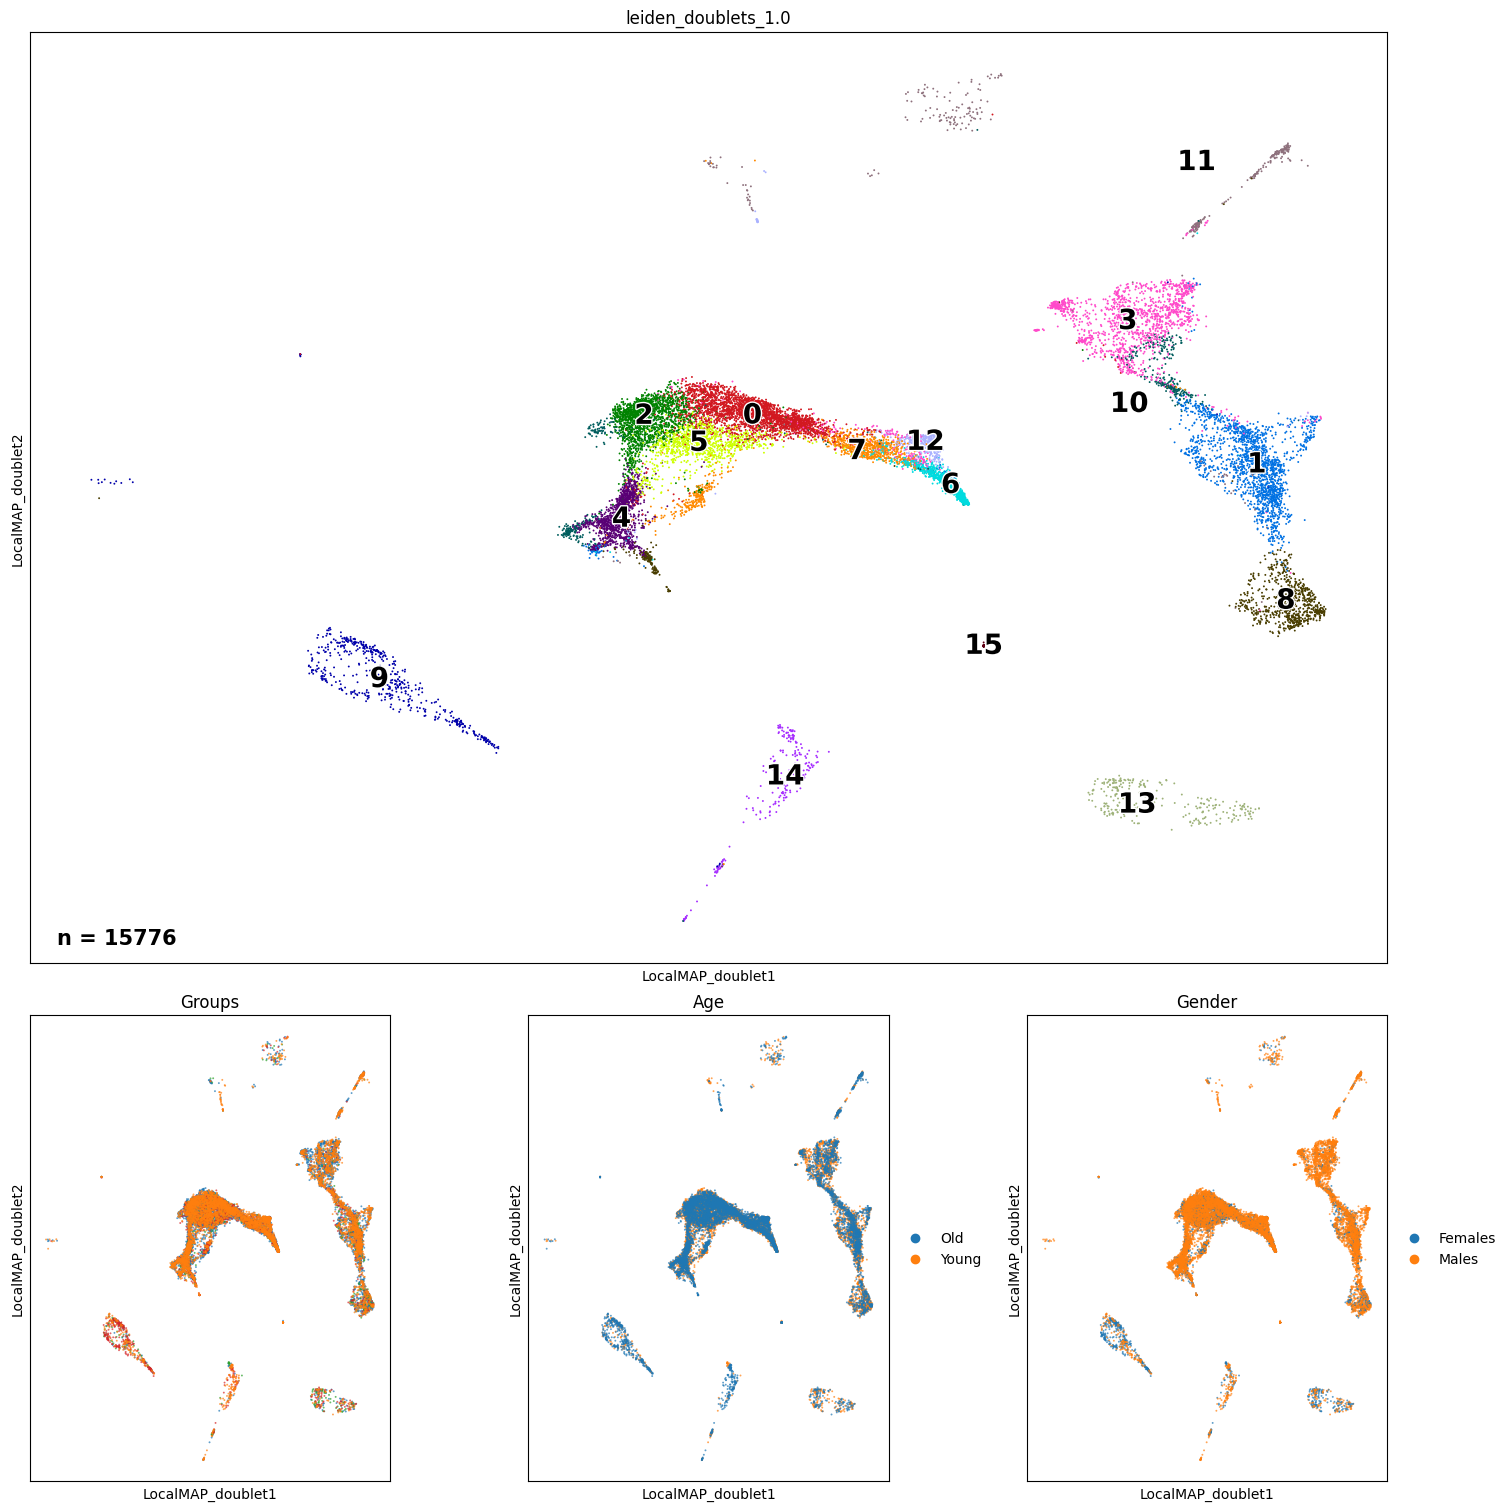

In [ ]:
key = "leiden_doublets"
resolution = 1
cluster_key = f"{key}_{resolution:.1f}"
runCluster = True
embedding = "LocalMAP_doublet"

# leiden clustering
if runCluster is True:
    Cluster(adata, key, [0.5, 0.7, 1.0])

# figure prept
cluster_c = color_gen(adata.obs[cluster_key])
f = plt.figure(figsize=(15, 15), layout="constrained")

axs = f.subplots(3, 3)
gs = axs[0, 0].get_gridspec()
for rs in axs[:]:
    for ax in rs[:]:
        ax.remove()

# Large LocalMAP plot
ax = f.add_subplot(gs[:2, :])
sc.pl.embedding(
    adata,
    basis=embedding,
    color=cluster_key,
    ax=ax,
    show=False,
    legend_loc="on data",
    legend_fontoutline=2,
    legend_fontsize=20,
    palette=cluster_c.to_list(),
)
ax.annotate(
    f"n = {adata.shape[0]}",
    (0.02, 0.02),
    fontweight="bold",
    fontsize=15,
    xycoords="axes fraction",
)

ax = f.add_subplot(gs[2, 0])
sc.pl.embedding(
    adata,
    basis=embedding,
    color=["Groups"],
    ax=ax,
    show=False,
    alpha=0.7,
    legend_loc="none",
)
ax = f.add_subplot(gs[2, 1])
sc.pl.embedding(adata, basis=embedding, color=["Age"], ax=ax, show=False, alpha=0.7)
ax = f.add_subplot(gs[2, 2])
sc.pl.embedding(adata, basis=embedding, color=["Gender"], ax=ax, show=False, alpha=0.7)

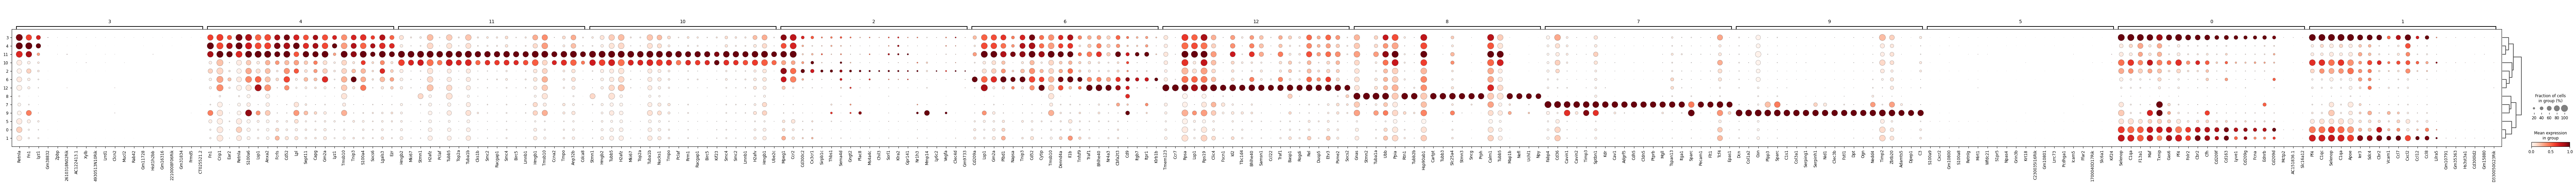

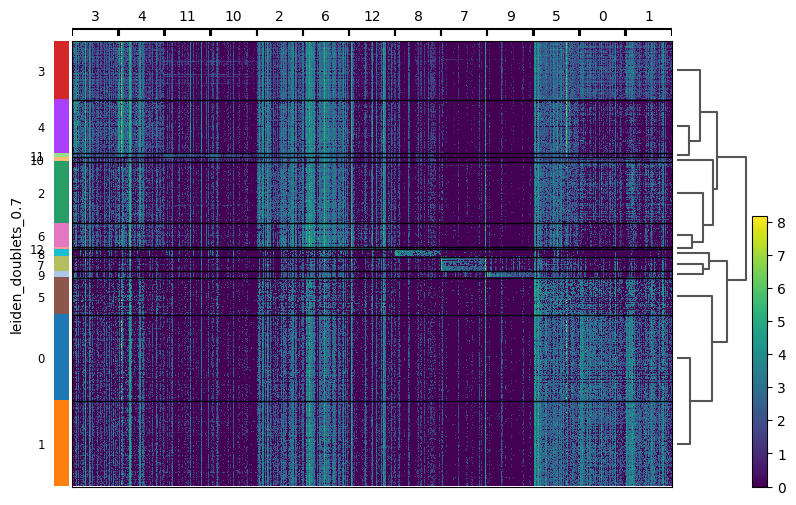

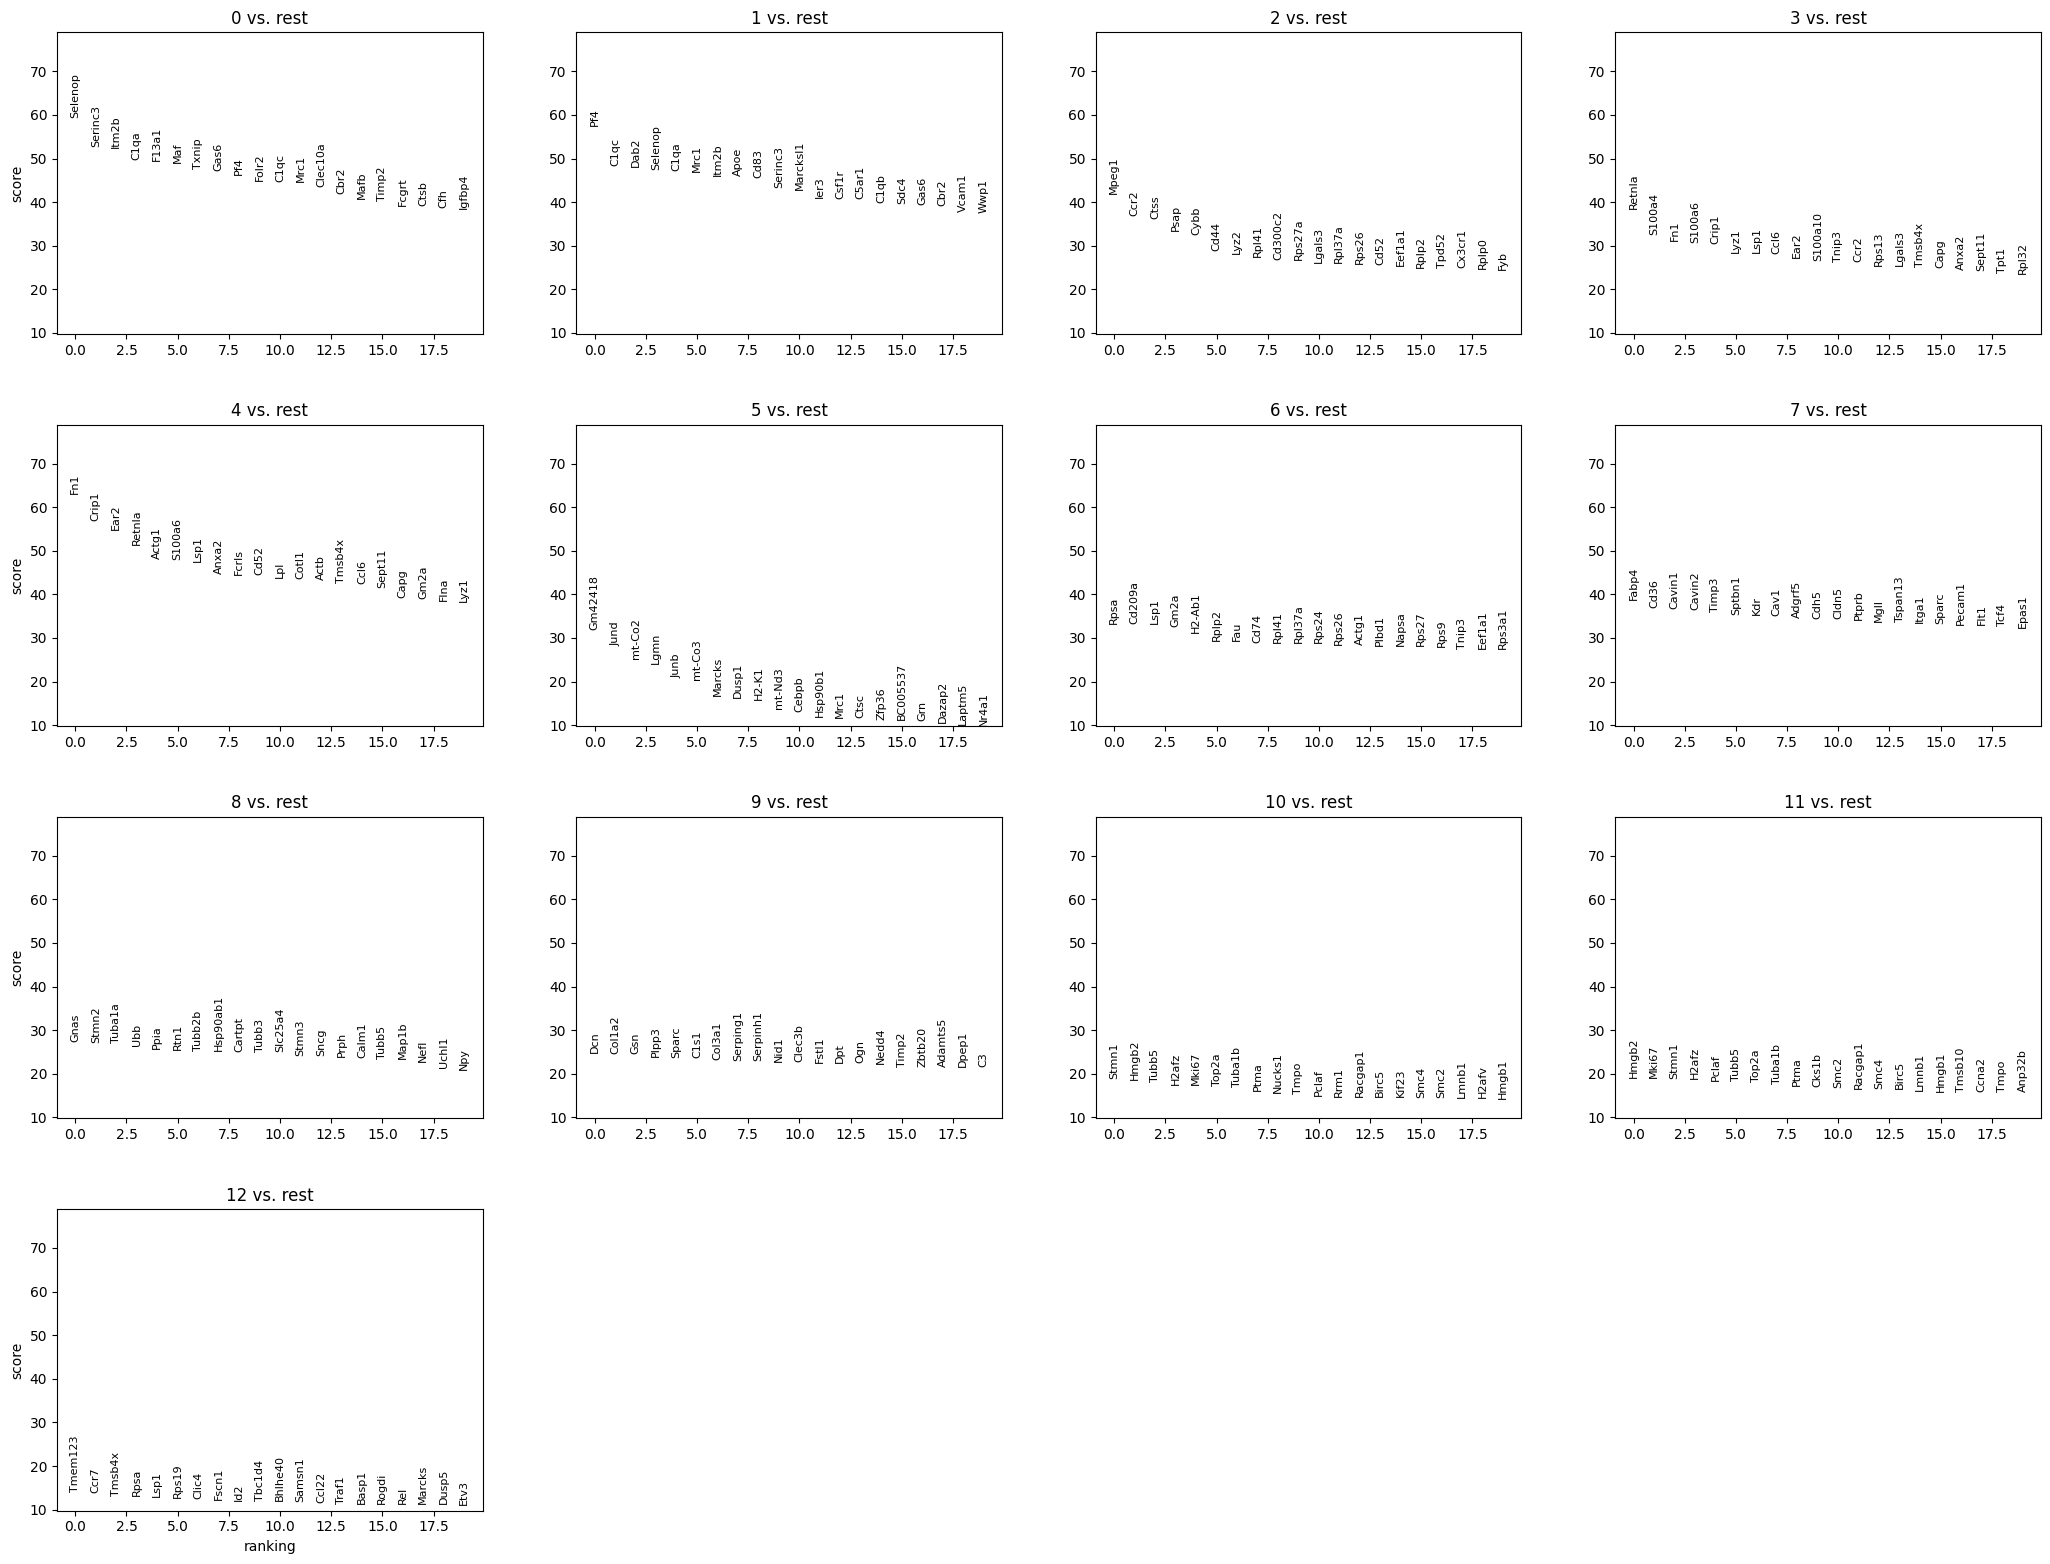

In [ ]:
key = "leiden_doublets"
resolution = 0.7
cluster_key = f"{key}_{resolution:.1f}"
de_key = "DEGs"
runDEGs = True

if runDEGs is True:
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        key_added=de_key,
        use_raw=False,
        layer="normalized",
        method="wilcoxon",
    )

sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby=cluster_key,
    key=de_key,
    standard_scale="var",
    n_genes=20,
    min_logfoldchange=2,
)

sc.pl.rank_genes_groups_heatmap(
    adata, key=de_key, groupby=cluster_key, layer="normalized", n_genes=50
)

sc.pl.rank_genes_groups(adata, adata.obs[cluster_key].cat.categories, key=de_key)

predicted_doublet-scDblFinder         1429
predicted_doublet-DoubletFinder       1067
predicted_doublet-doubletdetection    2850
predicted_doublet-scrublet              13
dtype: int64


516

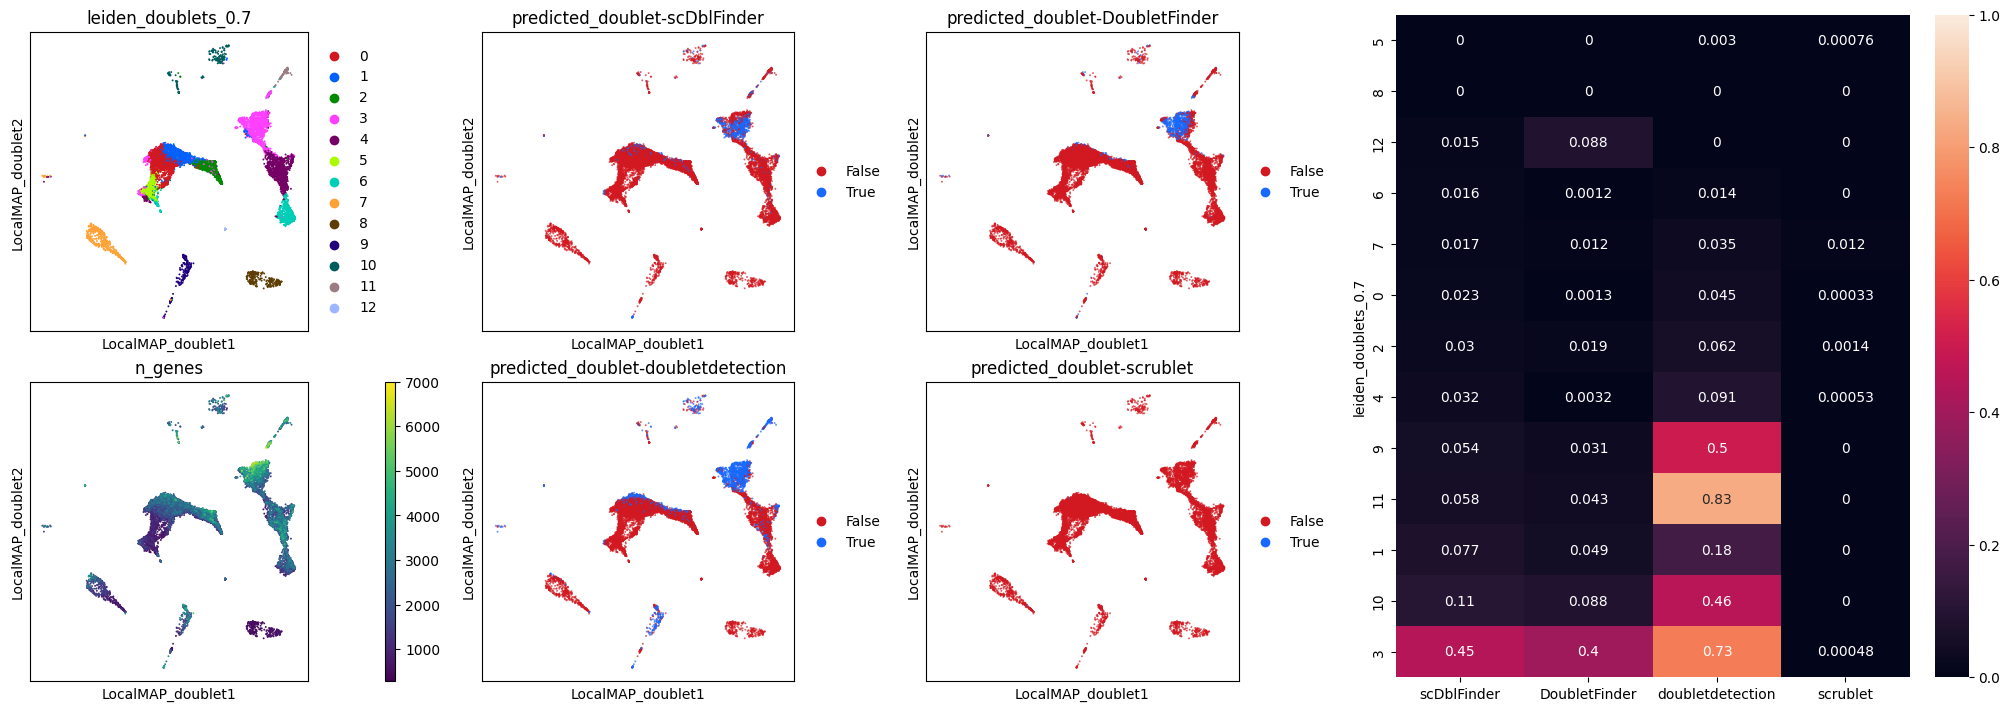

In [36]:
key = "leiden_doublets"
resolution = 0.7
cluster_key = f"{key}_{resolution:.1f}"

check_Doublets(adata, "LocalMAP_doublet", cluster_key)
print(adata.obs[[f"predicted_doublet-{m}" for m in DOUBLETMETHODS]].sum(axis=0))
multi_doublet = adata.obs[
    [f"predicted_doublet-{m}" for m in ["scDblFinder", "DoubletFinder"]]
].all(axis=1)
multi_doublet.sum(axis=0)

516


Text(0.02, 0.02, 'n = 15776')

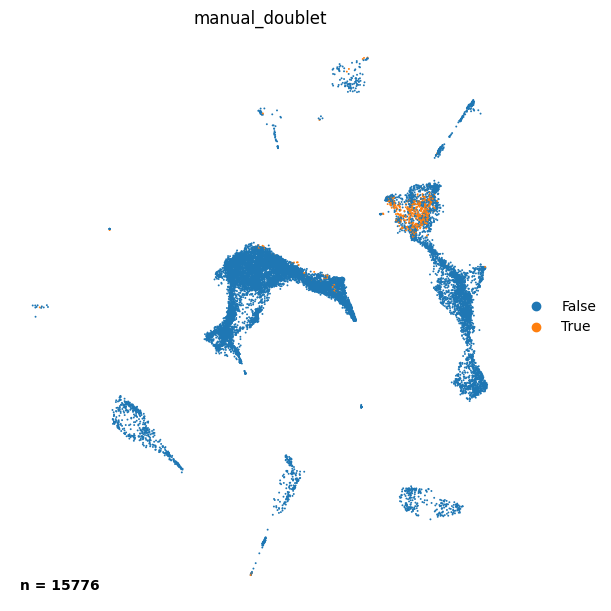

In [ ]:
adata.obs["manual_doublet"] = multi_doublet
print(adata.obs["manual_doublet"].sum())

f, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))
sc.pl.embedding(
    adata, basis=embedding, color="manual_doublet", frameon=False, ax=ax, show=False
)
ax.annotate(
    f"n = {adata.shape[0]}",
    (0.02, 0.02),
    fontweight="bold",
    fontsize=10,
    xycoords="axes fraction",
)

In [63]:
# save
annotation = "doublet_cleaned"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
os.makedirs(savedir, exist_ok=True)
adata[~adata.obs["manual_doublet"]].write(os.path.join(savedir, f"{annotation}.h5ad"))

# Reload

In [7]:
# load
annotation = "doublet_cleaned"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
adata = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))